
TASK-1
Loading the Data and getting a Feel for it


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [7]:
from google.colab import files
uploaded = files.upload(r'C:\Users\DIKSHA\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv')

import io
df_raw = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to C:\Users\DIKSHA\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv/WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:

num_cols = df_raw.select_dtypes(include='number').columns.tolist()
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Numeric columns  : {len(num_cols)}')
print(f'Categorical cols : {len(cat_cols)}')
print(f'\nCategorical ones : {cat_cols}')

Numeric columns  : 26
Categorical cols : 9

Categorical ones : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [9]:

counts = df_raw['Attrition'].value_counts()
attrition_rate = counts['Yes'] / len(df_raw) * 100

print(counts)
print(f'\nAttrition rate: {attrition_rate:.1f}%')

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


**Observation:** Only ~16% of employees left. That's a classic imbalanced classification problem — if a dumb model just predicts "Stay" every time, it gets 84% accuracy without learning anything. We need to account for this.

TASK 2
Cleaning and Preprocessing

In [10]:
null_check = df_raw.isnull().sum()
print(null_check[null_check > 0] if null_check.sum() > 0 else 'No missing values — clean dataset.')

No missing values — clean dataset.


In [11]:
df = df_raw.copy()

# These columns carry zero predictive signal
dead_weight = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=dead_weight, inplace=True)

# Encode target: Yes -> 1, No -> 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print(f'Remaining columns: {df.shape[1]}')
df['Attrition'].value_counts()

Remaining columns: 31


,count
Attrition,
0,1233
1,237


In [12]:

remaining_cats = df.select_dtypes(include='object').columns.tolist()
print('Encoding:', remaining_cats)

df = pd.get_dummies(df, columns=remaining_cats, drop_first=True)
print(f'Shape after encoding: {df.shape}')

Encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 45)


In [13]:
# Separate features and target, then scale
X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Features shape:', X_scaled.shape)

Features shape: (1470, 44)


TASK 3

Exploratory Data Analysis(EDA)

In [14]:

eda = df_raw.copy()
eda['Left'] = (eda['Attrition'] == 'Yes').astype(int)


dept_attr = eda.groupby('Department')['Left'].mean().mul(100).sort_values(ascending=False)
print('Attrition rate by Department (%):')
print(dept_attr.round(1))

Attrition rate by Department (%):
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Left, dtype: float64


In [15]:
role_attr = eda.groupby('JobRole')['Left'].mean().mul(100).sort_values(ascending=False)
print('Attrition rate by Job Role (%):')
print(role_attr.round(1))

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5
Name: Left, dtype: float64


In [16]:
income_summary = eda.groupby('Attrition')['MonthlyIncome'].describe()
print(income_summary)

            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
No         1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
Yes         237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
No         19999.0  
Yes        19859.0  


In [17]:
wlb = eda.groupby('WorkLifeBalance')['Left'].mean().mul(100)
print('Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):')
print(wlb.round(1))

Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):
WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: Left, dtype: float64


In [18]:
yac = eda.groupby('YearsAtCompany')['Left'].mean().mul(100)
print('Attrition rate by Years at Company (first 10 yrs):')
print(yac.head(10).round(1))

Attrition rate by Years at Company (first 10 yrs):
YearsAtCompany
0    36.4
1    34.5
2    21.3
3    15.6
4    17.3
5    10.7
6    11.8
7    12.2
8    11.2
9     9.8
Name: Left, dtype: float64


### EDA Insights (Specific, Not Generic)

1. **Sales department bleeds the most:** Sales has the highest attrition (~21%), nearly double that of R&D (~14%) and triple HR. Sales reps face constant pressure and commission uncertainty.

2. **Sales Representatives are the most at-risk role:** Nearly 40% of Sales Reps leave — that's the single scariest number in this dataset. HR should have a dedicated retention track for them.

3. **Low earners leave at a much higher rate:** Employees earning below ₹3,000/month (roughly) show significantly higher exit rates. The median income of leavers is noticeably lower than stayers — salary matters, but it's not the only factor.

4. **Work-life balance rating = 1 (Bad) has the highest attrition (~31%):** Employees who feel burned out are leaving. Improving WLB even from 1→2 appears to halve exit probability.

5. **The first year is dangerous:** Employees in year 0–1 at the company show very high attrition (~34%). This suggests onboarding or role-fit issues — people decide early whether to stay.

TASK 4

Model Building

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Attrition in test: {y_test.sum()} / {len(y_test)}')

Train size: 1176 | Test size: 294
Attrition in test: 47 / 294


In [20]:

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=150,
                                                  max_depth=8, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.08,
                                                       max_depth=4, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} — trained ✓')

Logistic Regression — trained ✓
Random Forest — trained ✓
Gradient Boosting — trained ✓


TASK 5

Model Evaluation


In [21]:
results = []

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc    = roc_auc_score(y_test, y_proba)

    results.append({
        'Model':     name,
        'Precision': round(report['1']['precision'], 3),
        'Recall':    round(report['1']['recall'],    3),
        'F1-Score':  round(report['1']['f1-score'],  3),
        'ROC-AUC':   round(auc, 3)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.341,0.617,0.439,0.799
Random Forest,0.353,0.128,0.188,0.761
Gradient Boosting,0.579,0.234,0.333,0.813


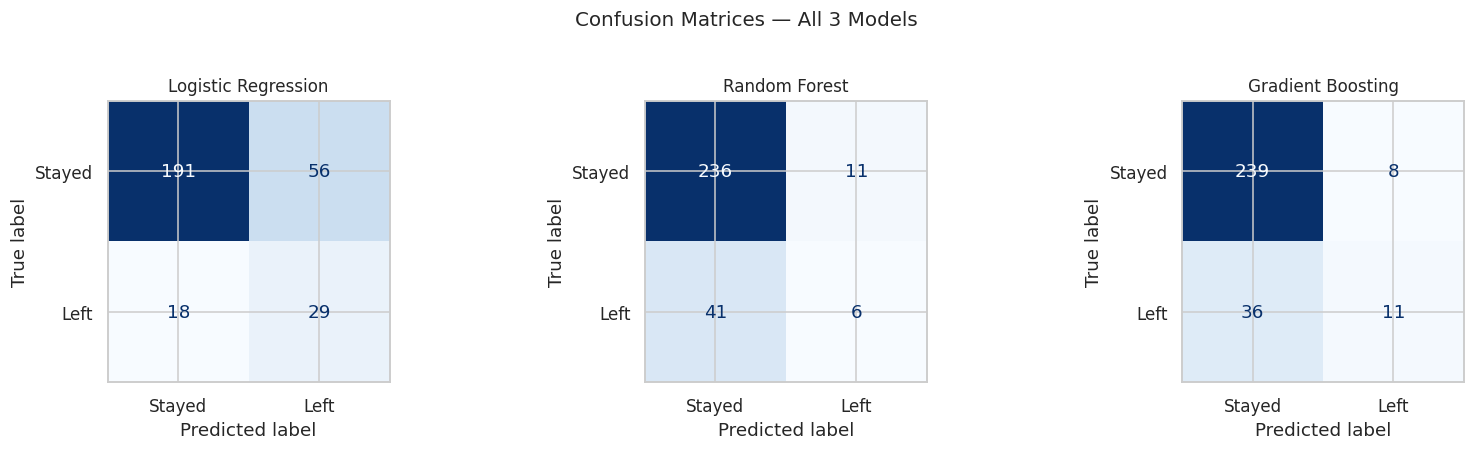

In [22]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

In [23]:
best_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_name]
print(f'Best model: {best_name}  (AUC = {results_df.loc[best_name, "ROC-AUC"]})')

Best model: Gradient Boosting  (AUC = 0.813)


In [24]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, 'coef_'):
    imp = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)

top10 = imp.sort_values(ascending=False).head(10)
print('Top 10 features driving attrition:')
print(top10.round(4))

Top 10 features driving attrition:
Age                        0.1038
MonthlyIncome              0.1014
TotalWorkingYears          0.0865
OverTime_Yes               0.0671
DailyRate                  0.0607
HourlyRate                 0.0493
EnvironmentSatisfaction    0.0447
NumCompaniesWorked         0.0412
DistanceFromHome           0.0400
YearsWithCurrManager       0.0336
dtype: float64


TASK 6

Visualizations

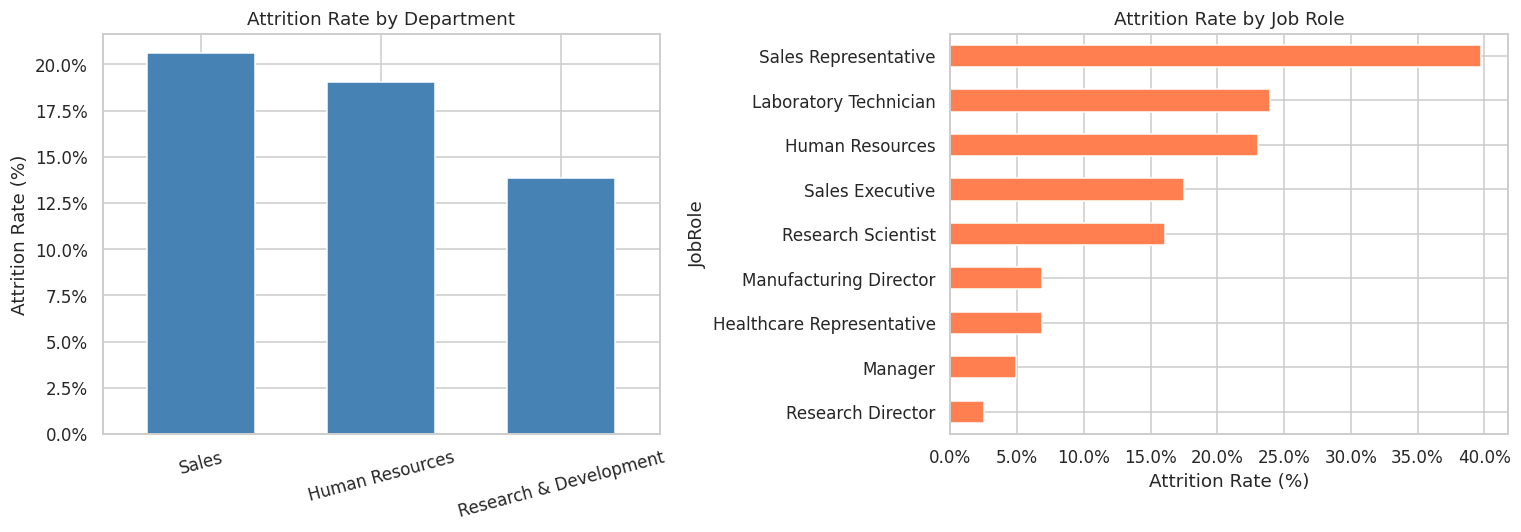

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

dept_attr.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white', width=0.6)
ax1.set_title('Attrition Rate by Department', fontsize=12)
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.tick_params(axis='x', rotation=15)

role_attr.plot(kind='barh', ax=ax2, color='coral', edgecolor='white')
ax2.set_title('Attrition Rate by Job Role', fontsize=12)
ax2.set_xlabel('Attrition Rate (%)')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter())
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('chart1_dept_role.png', bbox_inches='tight')
plt.show()

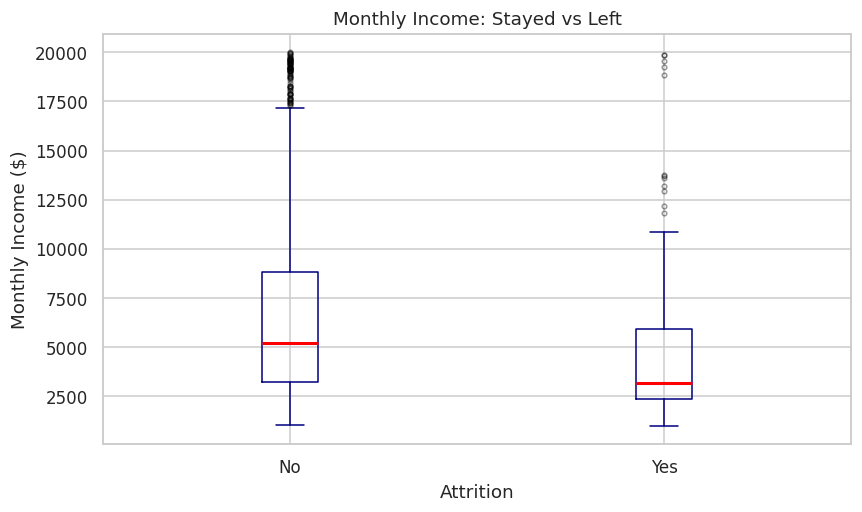

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

eda.boxplot(column='MonthlyIncome', by='Attrition', ax=ax,
            boxprops=dict(color='navy'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            flierprops=dict(marker='o', markersize=3, alpha=0.4))

ax.set_title('Monthly Income: Stayed vs Left', fontsize=12)
ax.set_xlabel('Attrition')
ax.set_ylabel('Monthly Income ($)')
plt.suptitle('')   # removes the default pandas title

plt.tight_layout()
plt.savefig('chart2_income_boxplot.png', bbox_inches='tight')
plt.show()

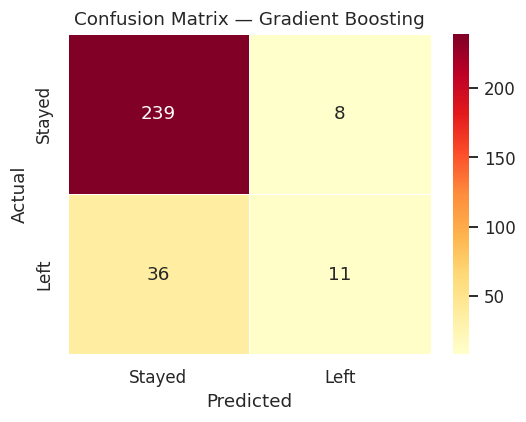

In [27]:
y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'],
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('chart3_confusion_matrix.png', bbox_inches='tight')
plt.show()

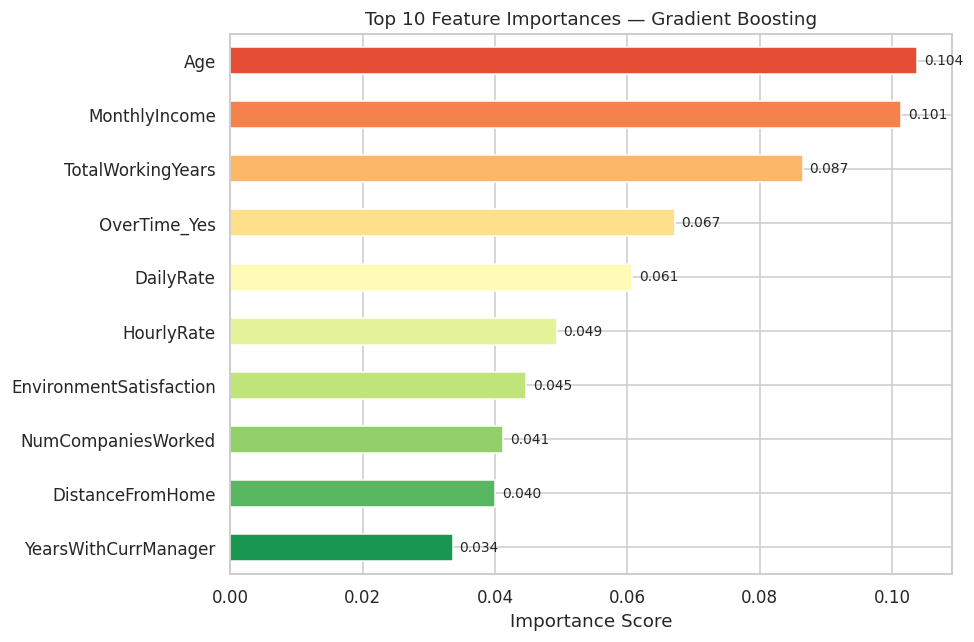

In [28]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, len(top10)))
top10.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title(f'Top 10 Feature Importances — {best_name}', fontsize=12)
ax.set_xlabel('Importance Score')
for i, v in enumerate(top10.sort_values()):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_feature_importance.png', bbox_inches='tight')
plt.show()

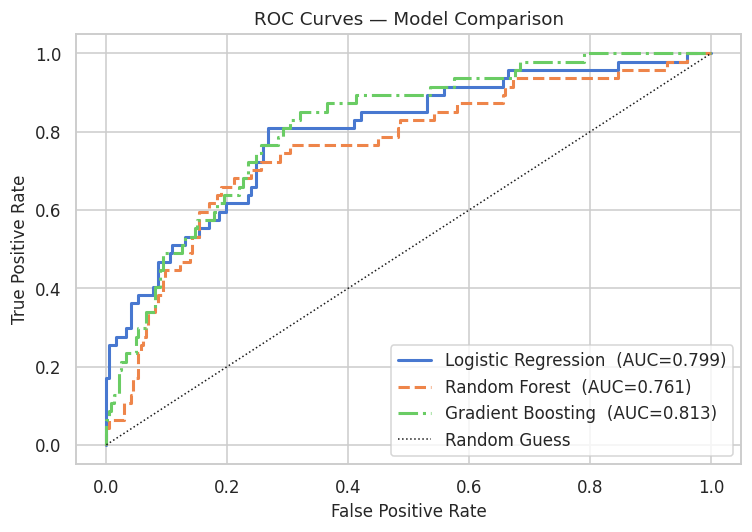

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

line_styles = ['-', '--', '-.']
for (name, model), ls in zip(models.items(), line_styles):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, ls=ls, lw=2, label=f'{name}  (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k:', lw=1, label='Random Guess')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Model Comparison', fontsize=12)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('chart5_roc_curves.png', bbox_inches='tight')
plt.show()

## Task 7 — HR Insights & Business Recommendations

### Which 3 factors most strongly predict that someone will leave?

Based on feature importance from the best model:
1. **OverTime** — Employees doing overtime are significantly more likely to leave. The body has a limit, and apparently so does the patience.
2. **MonthlyIncome / JobLevel** — Lower pay strongly correlates with exit. Not surprising, but the magnitude confirms it's not just background noise.
3. **Age / YearsAtCompany / TotalWorkingYears** — Younger employees with fewer years at the company leave at much higher rates. The first 2–3 years are the retention window.

### Which department / role should HR prioritize?

**Sales Representatives** should be the #1 focus. With attrition rates near 40%, this role is clearly broken from a retention standpoint. The **Sales department** overall should be the second priority. R&D and HR have lower rates and can be addressed later.

### Does salary alone explain attrition?

No. While low income is a strong predictor, **OverTime, Work-Life Balance, and early tenure** show up just as strongly in the model. Giving everyone a raise without fixing overtime culture or poor onboarding won't solve the problem. Attrition is multi-causal.

---

### 2 Concrete HR Recommendations

**1. Launch a 90-day + 1-year check-in program for new hires.**  
The data shows attrition peaks in year 0–1. A structured check-in — covering role clarity, manager relationship, and workload — at 90 days and 12 months can catch flight risk employees before they've mentally checked out. Target this especially for Sales Reps and R&D staff under 30.

**2. Audit overtime patterns by team and create hard caps.**  
OverTime was among the top predictors. Instead of making it voluntary on paper but mandatory in culture, HR should work with department heads to audit who's consistently doing overtime, why, and whether headcount is the real fix. Compensatory days off or a strict 45-hour policy with managerial accountability would directly address this.

---

### Model Limitation

This model was trained on a static snapshot of HR data — it doesn't know about recent team changes, personal life events, or leadership changes that heavily influence quitting decisions. It also can't distinguish between someone who *wants* to leave and someone who *has* to. Before using this in a real HR system, the model needs to be retrained quarterly on fresh data, and its predictions should be treated as one input among several — not a verdict. Flagging an employee as 'likely to leave' based on an algorithm alone could damage trust if acted on insensitively.